# Дискретно-событийная модель SIR: сравнение версий

Сравниваются три версии одной и той же модели:
дискретно-событийная с экспоненциальной длительностью болезни,
дискретно-событийная с фиксированной длительностью $1/\gamma$
и детерминированная модель на дифференциальных уравнениях.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV

script_name = "sir_des_compare"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Параметры модели

Параметры те же, что и в базовом прогоне.

In [2]:
tmax = 40.0
u0 = [990, 10, 0]
p = [0.05, 10.0, 0.25]

3-element Vector{Float64}:
  0.05
 10.0
  0.25

## Экспоненциальная длительность болезни

In [3]:
Random.seed!(1234)
m_exp = MakeSIRModel(u0, p)
activate(m_exp)
sir_run(m_exp, tmax)
df_exp = out(m_exp)

Row,t,S,I,R
,Float64,Int64,Int64,Int64
1,0.0,990,10,0
2,0.110851,989,11,0
3,0.249585,988,12,0
4,0.314392,987,13,0
5,0.418738,987,12,1
6,0.457041,987,11,2
7,0.528895,986,12,2
8,0.619502,985,13,2
9,0.657704,984,14,2


## Фиксированная длительность болезни

Каждый больной выздоравливает ровно через $1/\gamma = 4$ единицы времени.
Зерно генератора то же самое.

In [4]:
Random.seed!(1234)
m_fix = MakeSIRModel(u0, p; fixed = true)
activate(m_fix)
sir_run(m_fix, tmax)
df_fix = out(m_fix)

Row,t,S,I,R
,Float64,Int64,Int64,Int64
1,0.0,990,10,0
2,0.112134,989,11,0
3,0.250891,988,12,0
4,0.315478,987,13,0
5,0.623633,986,14,0
6,0.662115,985,15,0
7,0.684864,984,16,0
8,0.760045,983,17,0
9,0.814126,982,18,0


## Детерминированная модель

В детерминированной модели скорость заражения равна $\beta c S I / N$,
а скорость выздоровления $\gamma I$.

In [5]:
df_ode = sir_ode_solution(u0, p, tmax)

Row,t,S,I,R
,Float64,Float64,Float64,Float64
1,0.0,990.0,10.0,0.0
2,0.1,989.499,10.2479,0.253087
3,0.2,988.986,10.5017,0.512444
4,0.3,988.46,10.7615,0.77822
5,0.4,987.922,11.0274,1.05057
6,0.5,987.371,11.2996,1.32964
7,0.6,986.806,11.5781,1.6156
8,0.7,986.228,11.8632,1.9086
9,0.8,985.636,12.155,2.20882


## Сравнение показателей

In [6]:
df_cmp = DataFrame([
    merge((version = "Экспоненциальная",), map(float, sir_metrics(df_exp))),
    merge((version = "Фиксированная",), map(float, sir_metrics(df_fix))),
    merge((version = "ОДУ",), map(x -> round(x, digits = 1), sir_metrics(df_ode))),
])
CSV.write(datadir("sir_des_compare.csv"), df_cmp)
println(df_cmp)

3×4 DataFrame
 Row │ version           peak_I   t_peak   final_R 
     │ String            Float64  Float64  Float64 
─────┼─────────────────────────────────────────────
   1 │ Экспоненциальная    174.0  17.8722    751.0
   2 │ Фиксированная       316.0  12.0611    833.0
   3 │ ОДУ                 158.5  17.5       775.7


## Графики

Слева число больных, справа число переболевших.

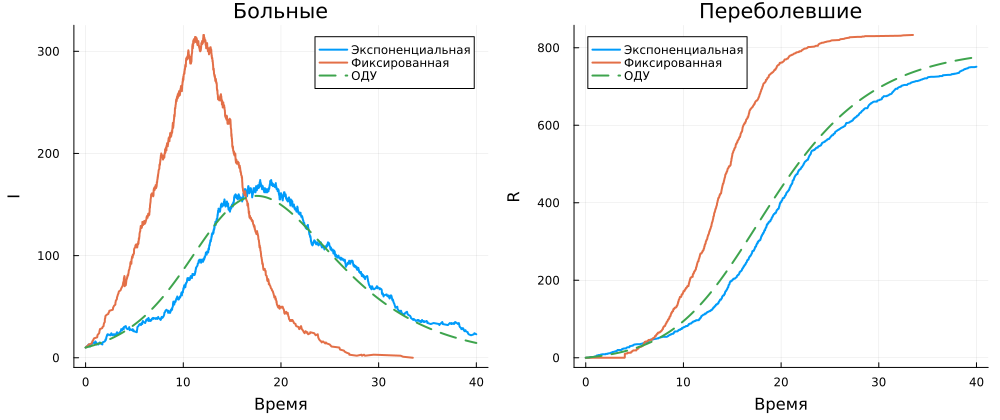

In [7]:
p1 = plot(df_exp.t, df_exp.I, label = "Экспоненциальная", xlabel = "Время", ylabel = "I", title = "Больные", linewidth = 2)
plot!(p1, df_fix.t, df_fix.I, label = "Фиксированная", linewidth = 2)
plot!(p1, df_ode.t, df_ode.I, label = "ОДУ", linestyle = :dash, linewidth = 2)
p2 = plot(df_exp.t, df_exp.R, label = "Экспоненциальная", xlabel = "Время", ylabel = "R", title = "Переболевшие", linewidth = 2, legend = :topleft)
plot!(p2, df_fix.t, df_fix.R, label = "Фиксированная", linewidth = 2)
plot!(p2, df_ode.t, df_ode.R, label = "ОДУ", linestyle = :dash, linewidth = 2)
plt_cmp = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
savefig(plt_cmp, plotsdir("sir_des_compare.png"))
plt_cmp